# Garmin Running EDA
**Dec 2024 – Apr 2026 · 123 runs · 402 miles**

Exploratory analysis of 16 months of personal Garmin GPS running data.
Data was parsed from the Garmin Connect export, cleaned in `src/clean.py`, and feature-engineered in `src/features.py`.

---


## Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve().parent))

import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from src.clean import clean_activities, filter_runs
from src.features import build_features

DATA = Path().resolve().parent / "data"
OUT  = Path().resolve().parent / "outputs"
OUT.mkdir(exist_ok=True)

raw  = clean_activities(DATA / "garmin_activities.json")
runs = filter_runs(raw)
df   = build_features(runs)

# Drop 4 outlier walk/jog activities (pace > 15 min/mile) for cleaner visuals
df_runs = df[df["avg_pace_min_per_mile"] < 15].copy()

print(f"Runs: {len(df)} | Date range: {df['datetime_local'].min().date()} → {df['datetime_local'].max().date()}")
print(f"Total miles: {df['distance_miles'].sum():.1f} | Avg pace: {df['avg_pace_min_per_mile'].median():.2f} min/mi")

Runs: 123 | Date range: 2024-12-26 → 2026-04-06
Total miles: 402.2 | Avg pace: 8.96 min/mi


In [2]:
# Shared style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

BLUE   = "#2563EB"
RED    = "#DC2626"
GREEN  = "#16A34A"
ORANGE = "#EA580C"
GRAY   = "#6B7280"

ZONE_COLORS = {
    "Easy":      "#22C55E",
    "Moderate":  "#84CC16",
    "Hard":      "#F59E0B",
    "Very Hard": "#EF4444",
    "Maximum":   "#7C3AED",
}

def pace_fmt(x, _):
    mins = int(x)
    secs = int(round((x - mins) * 60))
    return f"{mins}:{secs:02d}"

def save(name):
    plt.tight_layout()
    plt.savefig(OUT / name, dpi=150, bbox_inches="tight")
    plt.show()

---
## Quick Summary

Before diving into plots, a high-level snapshot of the dataset.


In [3]:
summary = df[["distance_miles", "avg_pace_min_per_mile", "avgHr", "cadence_spm",
              "duration_min", "elevationGain"]].describe().round(2)
summary.index.name = None
summary

,distance_miles,avg_pace_min_per_mile,avgHr,cadence_spm,duration_min,elevationGain
count,123.00,123.00,123.00,123.00,123.00,110.00
mean,3.27,9.22,168.35,159.71,30.46,31.76
std,1.85,2.05,14.96,12.08,18.52,30.17
min,0.32,4.82,91.00,106.11,1.56,0.00
25%,2.02,8.31,165.50,160.80,17.92,10.25
50%,3.01,8.96,172.00,163.14,26.17,26.50
75%,4.01,9.62,176.00,166.29,38.56,40.75
max,13.20,19.04,184.00,170.86,125.28,162.00


In [4]:
print(f"Avg runs/week:      {len(df) / ((df['datetime_local'].max() - df['datetime_local'].min()).days / 7):.1f}")
print(f"Effort zone split:  {df['effort_zone'].value_counts().to_dict()}")
print(f"Longest gap (days): {df['days_since_last_run'].max():.0f}")
print(f"Max weekly mileage: {df['weekly_miles'].max():.1f} mi")

Avg runs/week:      1.9
Effort zone split:  {'Very Hard': 79, 'Hard': 31, 'Moderate': 6, 'Easy': 5, 'Maximum': 2}
Longest gap (days): 17
Max weekly mileage: 18.0 mi


---
## 1 · Weekly Mileage Over Time

The 4-week rolling average smooths week-to-week noise to reveal the underlying training arc.

**Key observations:**
- Training started modestly (~5–7 mi/week) in early 2025 and built steadily through summer
- Volume peaked at **18 miles in a single week** in late October 2025 — the highest mileage block
- A clear **December 2025 trough** (down to ~2 mi/week) suggests a holiday break or injury
- 2026 shows a slow rebuild, with the most recent weeks trending back up toward 10+ mi/week


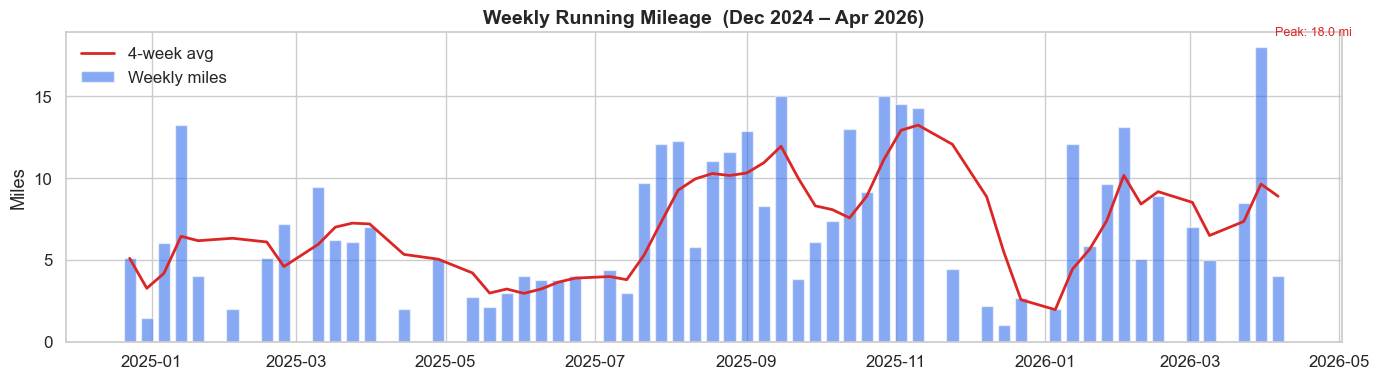

In [5]:
weekly = (
    df.groupby(df["datetime_local"].dt.to_period("W"))["distance_miles"]
    .sum()
    .reset_index()
)
weekly["week_start"] = weekly["datetime_local"].dt.start_time
weekly_ma = weekly["distance_miles"].rolling(4, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(weekly["week_start"], weekly["distance_miles"],
       width=5, color=BLUE, alpha=0.55, label="Weekly miles")
ax.plot(weekly["week_start"], weekly_ma, color=RED, lw=2, label="4-week avg")

ax.set_title("Weekly Running Mileage  (Dec 2024 – Apr 2026)", fontsize=14, fontweight="bold")
ax.set_ylabel("Miles")
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.legend(frameon=False)

peak_idx = weekly["distance_miles"].idxmax()
ax.annotate(f"Peak: {weekly['distance_miles'].max():.1f} mi",
            xy=(weekly.loc[peak_idx, "week_start"], weekly["distance_miles"].max()),
            xytext=(10, 8), textcoords="offset points",
            fontsize=9, color=RED)

save("01_weekly_mileage.png")

---
## 2 · Pace Distribution

Distribution of average pace across all runs (4 outlier walks >15 min/mile excluded).

**Key observations:**
- Distribution is approximately normal with a slight right skew
- **Median: 8:57/mile** — a solid recreational running pace
- Tight interquartile range (8:18–9:31) indicates fairly consistent effort pacing
- A cluster of faster runs below 7:00/mile represents shorter, higher-intensity efforts


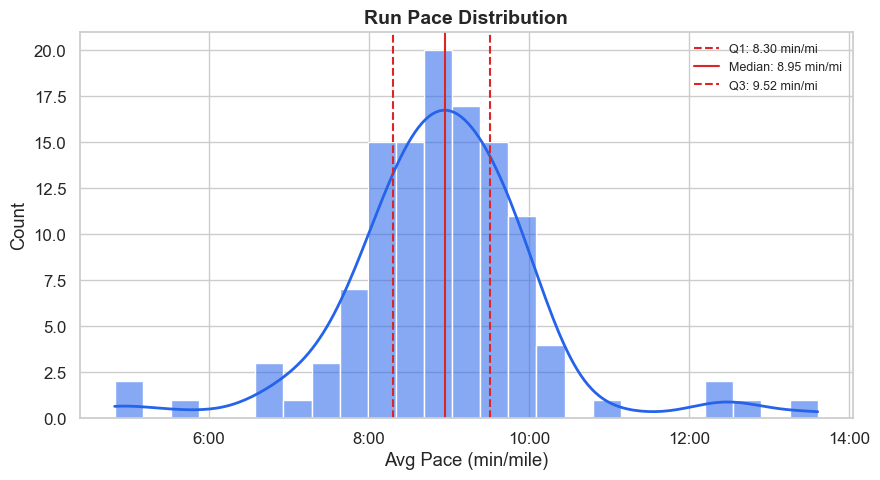

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.histplot(df_runs["avg_pace_min_per_mile"], bins=25, kde=True,
             color=BLUE, alpha=0.55, ax=ax, line_kws={"lw": 2})

for pct, label, ls in [
    (df_runs["avg_pace_min_per_mile"].quantile(0.25), "Q1", "--"),
    (df_runs["avg_pace_min_per_mile"].median(),        "Median", "-"),
    (df_runs["avg_pace_min_per_mile"].quantile(0.75), "Q3", "--"),
]:
    ax.axvline(pct, color=RED, ls=ls, lw=1.5, label=f"{label}: {pct:.2f} min/mi")

ax.set_title("Run Pace Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Avg Pace (min/mile)")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax.legend(frameon=False, fontsize=9)

save("02_pace_distribution.png")

---
## 3 · Pace vs. Heart Rate by Effort Zone

Each dot is one run. The y-axis is inverted so faster paces appear higher.

**Key observations:**
- The expected positive trend holds: higher HR correlates with faster pace — but the relationship is noisy
- **Very Hard runs (red)** cluster tightly at 170–185 bpm, spanning a wide pace range — this person pushes hard even on slower days
- **Hard runs (orange)** show the most pace variability at the same HR, suggesting varying course profiles or conditions
- The weak overall slope (dashed trend line) indicates this runner's pacing is more effort-driven than HR-disciplined


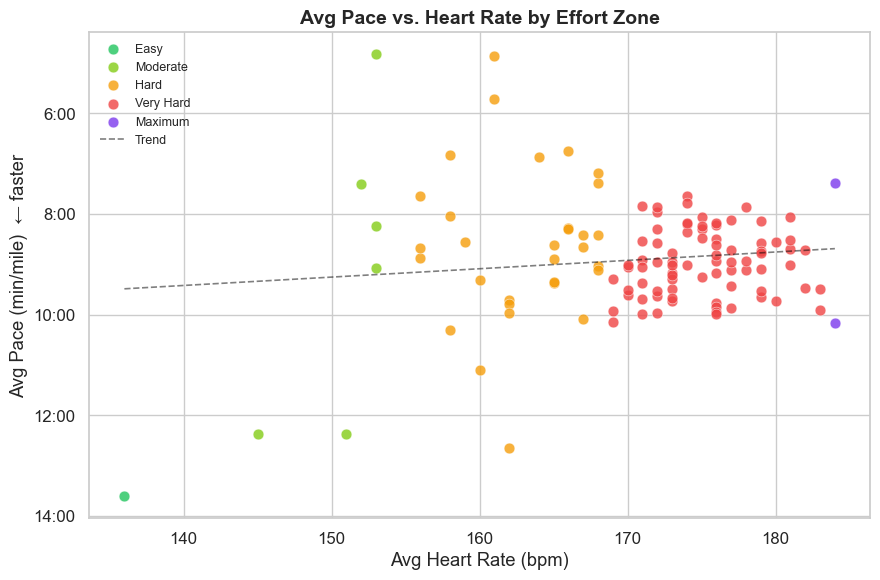

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))

for zone, grp in df_runs.groupby("effort_zone", observed=True):
    ax.scatter(grp["avgHr"], grp["avg_pace_min_per_mile"],
               color=ZONE_COLORS.get(str(zone), GRAY),
               label=str(zone), s=60, alpha=0.8, edgecolors="white", lw=0.4)

valid = df_runs[["avgHr", "avg_pace_min_per_mile"]].dropna()
m, b = np.polyfit(valid["avgHr"], valid["avg_pace_min_per_mile"], 1)
x_line = np.linspace(valid["avgHr"].min(), valid["avgHr"].max(), 100)
ax.plot(x_line, m * x_line + b, color="black", lw=1.2, ls="--", alpha=0.5, label="Trend")

ax.invert_yaxis()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(pace_fmt))
ax.set_title("Avg Pace vs. Heart Rate by Effort Zone", fontsize=14, fontweight="bold")
ax.set_xlabel("Avg Heart Rate (bpm)")
ax.set_ylabel("Avg Pace (min/mile)  ← faster")
ax.legend(frameon=False, fontsize=9, loc="upper left")

save("03_pace_vs_hr.png")

---
## 4 · VO₂Max and Aerobic Efficiency Over Time

VO₂Max (blue, left axis) is Garmin's estimated aerobic capacity. Efficiency Factor (orange, right axis) is speed-per-HR-beat — a proxy for running economy.

**Key observations:**
- VO₂Max rose from **46 → 50.7** between January and June 2025, a meaningful +4.7 point gain over 6 months of consistent training
- Both metrics declined together through Q3–Q4 2025, tracking the mileage drop seen in Plot 1
- The efficiency factor is noisier month-to-month, as it's sensitive to course difficulty and weather — but its overall trajectory mirrors VO₂Max
- **Takeaway:** the June 2025 peak represents the best aerobic fitness of this 16-month period


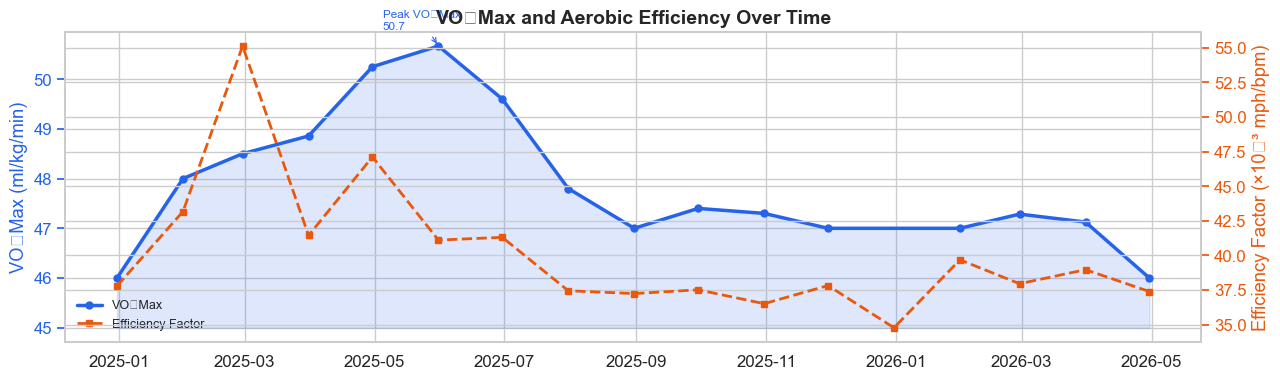

In [8]:
vo2_df = df[df["vO2MaxValue"].notna()].copy()
monthly_vo2 = vo2_df.set_index("datetime_local")["vO2MaxValue"].resample("ME").mean().dropna()
monthly_ef  = df.set_index("datetime_local")["efficiency_factor"].resample("ME").mean().dropna()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.plot(monthly_vo2.index, monthly_vo2.values,
         color=BLUE, lw=2.5, marker="o", ms=5, label="VO₂Max")
ax1.fill_between(monthly_vo2.index, monthly_vo2.values,
                 monthly_vo2.min() - 1, alpha=0.15, color=BLUE)

ax2.plot(monthly_ef.index, monthly_ef.values,
         color=ORANGE, lw=2, ls="--", marker="s", ms=4, label="Efficiency Factor")

peak_date = monthly_vo2.idxmax()
ax1.annotate(f"Peak VO₂Max\n{monthly_vo2.max():.1f}",
             xy=(peak_date, monthly_vo2.max()),
             xytext=(-40, 12), textcoords="offset points",
             fontsize=8.5, color=BLUE,
             arrowprops=dict(arrowstyle="->", color=BLUE, lw=0.8))

ax1.set_title("VO₂Max and Aerobic Efficiency Over Time", fontsize=14, fontweight="bold")
ax1.set_ylabel("VO₂Max (ml/kg/min)", color=BLUE)
ax1.tick_params(axis="y", colors=BLUE)
ax2.set_ylabel("Efficiency Factor (×10⁻³ mph/bpm)", color=ORANGE)
ax2.tick_params(axis="y", colors=ORANGE)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9, loc="lower left")

save("04_vo2max_efficiency.png")

---
## 5 · Total Training Time by HR Zone

Aggregate hours accumulated in each of Garmin's 5 HR zones across all 123 runs.

**Key observations:**
- **82% of all training time** is spent in Zones 4–5 (threshold and VO₂Max zones) — an extremely high-intensity distribution
- Only 9% of time is in Zones 1–2 (easy/aerobic base) — this is the opposite of the "80/20" polarized model most endurance coaches recommend
- This "threshold-heavy" pattern can drive rapid short-term gains (consistent with the VO₂Max rise through mid-2025) but carries higher injury and burnout risk long-term
- **Recommendation:** increasing Zone 1–2 volume would likely improve both durability and the efficiency factor over time


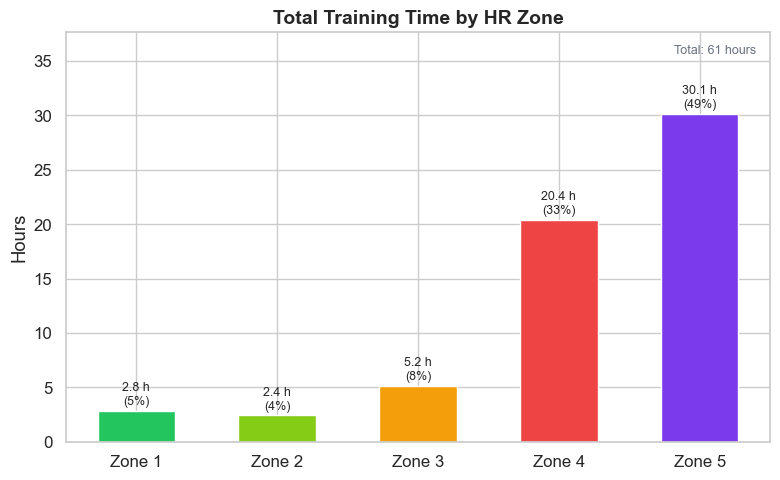

In [9]:
zone_hours = {f"Zone {i}": df[f"zone{i}_min"].sum() / 60 for i in range(1, 6)}
zone_pals  = ["#22C55E", "#84CC16", "#F59E0B", "#EF4444", "#7C3AED"]
total_hours = sum(zone_hours.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(zone_hours.keys(), zone_hours.values(),
              color=zone_pals, width=0.55, edgecolor="white")

for bar, val in zip(bars, zone_hours.values()):
    pct = val / total_hours * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f"{val:.1f} h\n({pct:.0f}%)", ha="center", va="bottom", fontsize=9)

ax.set_title("Total Training Time by HR Zone", fontsize=14, fontweight="bold")
ax.set_ylabel("Hours")
ax.set_ylim(0, max(zone_hours.values()) * 1.25)
ax.text(0.98, 0.97, f"Total: {total_hours:.0f} hours",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color=GRAY)

save("05_hr_zone_totals.png")

---
## 6 · Training Load: Fitness, Fatigue & Form (Banister Model)

**ATL** (Acute Training Load, red) = short-term fatigue — exponentially weighted TRIMP over ~7 days.
**CTL** (Chronic Training Load, blue) = long-term fitness — exponentially weighted TRIMP over ~42 days.
**TSB** (Training Stress Balance, green panel) = CTL − ATL. Positive = fresh; negative = fatigued.

**Key observations:**
- CTL never exceeded ~13 TRIMP units, reflecting the relatively low training volume throughout
- TSB is almost always positive — this runner is rarely in an accumulated fatigue state, which aligns with the frequent training gaps (Plot 1)
- The December 2025 training gap is visible as ATL drops sharply to near zero while CTL decays more slowly
- A "good race day" in this model would be shortly after a hard training block when TSB flips positive from negative


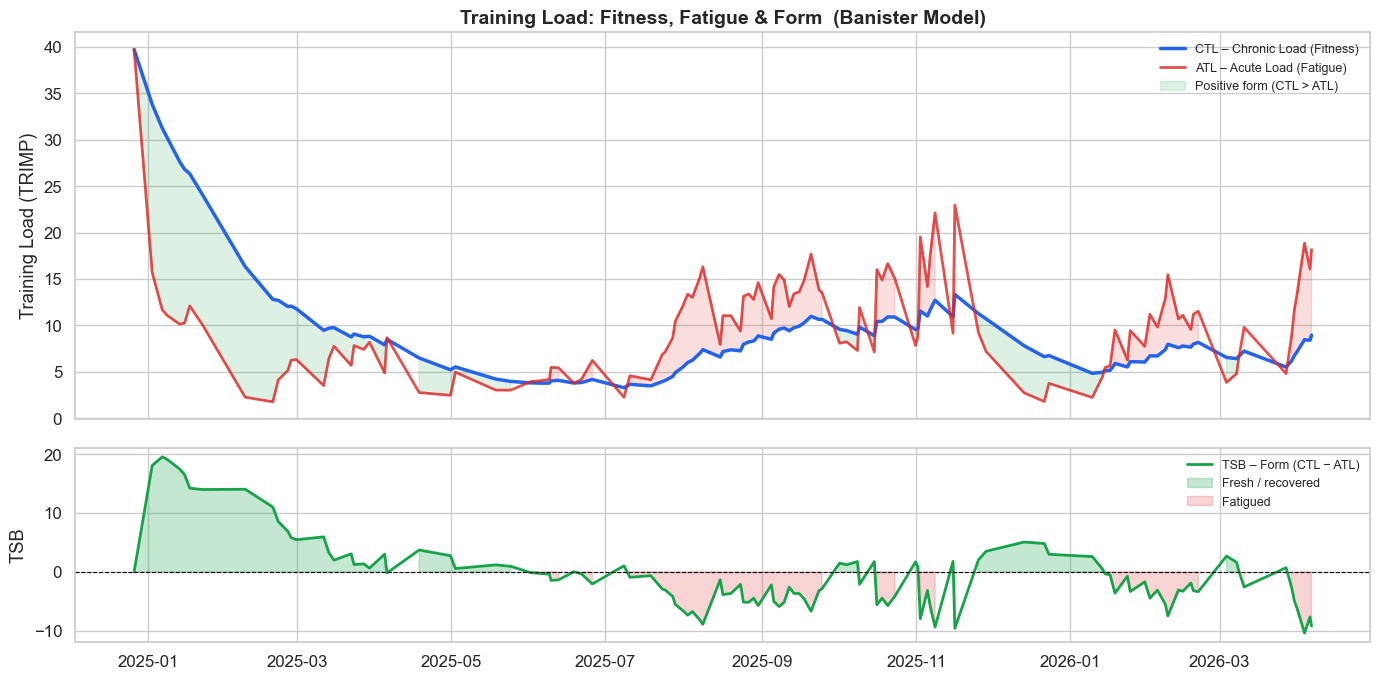

In [10]:
load = df.sort_values("datetime_local")
dates = load["datetime_local"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [2, 1]})

ax1.plot(dates, load["ctl"], color=BLUE, lw=2.5, label="CTL – Chronic Load (Fitness)")
ax1.plot(dates, load["atl"], color=RED,  lw=2,   label="ATL – Acute Load (Fatigue)", alpha=0.8)
ax1.fill_between(dates, load["ctl"], load["atl"],
                 where=load["ctl"] >= load["atl"], alpha=0.15, color=GREEN,
                 label="Positive form (CTL > ATL)")
ax1.fill_between(dates, load["ctl"], load["atl"],
                 where=load["ctl"] < load["atl"], alpha=0.15, color=RED)
ax1.set_ylabel("Training Load (TRIMP)")
ax1.legend(frameon=False, fontsize=9)
ax1.set_title("Training Load: Fitness, Fatigue & Form  (Banister Model)",
              fontsize=14, fontweight="bold")

ax2.plot(dates, load["tsb"], color=GREEN, lw=2, label="TSB – Form (CTL − ATL)")
ax2.axhline(0, color="black", lw=0.8, ls="--")
ax2.fill_between(dates, load["tsb"], 0, where=load["tsb"] >= 0,
                 color=GREEN, alpha=0.25, label="Fresh / recovered")
ax2.fill_between(dates, load["tsb"], 0, where=load["tsb"] < 0,
                 color=RED, alpha=0.20, label="Fatigued")
ax2.set_ylabel("TSB")
ax2.legend(frameon=False, fontsize=9)

save("06_training_load.png")

---
## 7 · Run Patterns by Day of Week

**Key observations:**
- **Saturday** is the most common run day (24 runs) — consistent with a weekend-warrior pattern
- **Sunday** produces the longest average runs (4.3 miles), suggesting it functions as the weekly long-run day
- **Wednesday** and **Friday** are the highest-frequency weekday run days, typically at shorter distances (~2.5–2.9 mi) — likely recovery or maintenance runs
- **Monday** is the least frequent day, which is the expected rest/recovery day after a long Sunday effort


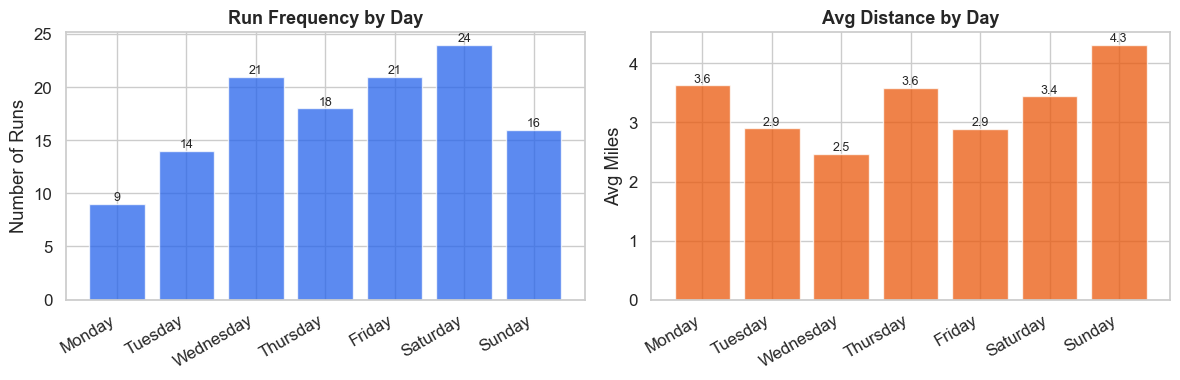

In [11]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = (df.groupby("day_name")
         .agg(count=("activityId", "count"), avg_miles=("distance_miles", "mean"))
         .reindex(dow_order))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars = ax1.bar(dow.index, dow["count"], color=BLUE, alpha=0.75, edgecolor="white")
ax1.set_title("Run Frequency by Day", fontsize=13, fontweight="bold")
ax1.set_ylabel("Number of Runs")
ax1.set_xticklabels(dow.index, rotation=30, ha="right")
for bar, val in zip(bars, dow["count"]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(int(val)), ha="center", fontsize=9)

bars2 = ax2.bar(dow.index, dow["avg_miles"], color=ORANGE, alpha=0.75, edgecolor="white")
ax2.set_title("Avg Distance by Day", fontsize=13, fontweight="bold")
ax2.set_ylabel("Avg Miles")
ax2.set_xticklabels(dow.index, rotation=30, ha="right")
for bar, val in zip(bars2, dow["avg_miles"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f"{val:.1f}", ha="center", fontsize=9)

save("07_day_of_week.png")

---
## Summary of Key Findings

| Theme | Finding |
|---|---|
| **Volume** | Low-moderate mileage runner; avg ~7 mi/week, peaked at 18 mi/week |
| **Intensity** | 82% of training time in Zones 4–5 — heavily threshold-heavy |
| **Fitness arc** | VO₂Max rose 46 → 50.7 (Jan–Jun 2025), then declined with lower volume |
| **Consistency** | 18 gaps > 7 days; training fragmented, especially Dec 2025 |
| **Weekly rhythm** | Saturday most frequent; Sunday is long-run day |
| **Training load** | TSB almost always positive — rarely accumulating meaningful fatigue |

### What to explore next
- **Statistical analysis**: Does training load predict VO₂Max changes? Is there a significant pace improvement over time?
- **Modeling**: Can we predict run pace from pre-run conditions (fatigue, days rest, time of day)?
- **Prescriptive**: How much Zone 1–2 volume is needed to shift the training distribution?
